In [ ]:
import pandas as pd
# import re
# import emoji
# from pathlib import Path
# data_dir = Path('../data')
offer_dataset=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/cleaned_combined_offer_final.csv')
# resume_dataset=pd.read_csv('/content/drive/MyDrive/Projet MASTER1/cleaned_combined_resume_final.csv')

In [ ]:
#Lecture et affichage Information dataframme
def read_data(data,column_name):
    print("\n __Aperçu des données :")
    print(data.head(3))
    # Afficher les informations sur le DataFrame
    print("\n __Informations sur les données :")
    print(data.info())
    print(" \n __Taille : \n",data.shape)
    print("\n __Information sur les Categories: \n",data[column_name].value_counts().reset_index())


In [ ]:
 read_data(offer_dataset,'Job Title_Category')


 __Aperçu des données :
    Job Title_Category                                    Job Description
0  Librarian/Archivist  job description 2: digital data services archi...
1  Mechanical Engineer  2. infrared sensor mechanical design engineer ...
2  Mechanical Engineer  3. ai packaging mechanical engineer (advanced ...

 __Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3309 entries, 0 to 3308
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Job Title_Category  3309 non-null   object
 1   Job Description     3309 non-null   object
dtypes: object(2)
memory usage: 51.8+ KB
None
 
 __Taille : 
 (3309, 2)

 __Information sur les Categories: 
            Job Title_Category  count
0              Data Scientist    704
1            AI/ML Specialist    697
2                Data Analyst    657
3          Software Developer    300
4               Data Engineer    269
5             

### DATA PREPARATION

### DATA PREPARATION

#### Label encoding : Category

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
offer_dataset['label'] = le.fit_transform(offer_dataset['Job Title_Category'])
offer_dataset.head()

,Job Title_Category,Job Description,label
0,Librarian/Archivist,job description 2: digital data services archi...,14
1,Mechanical Engineer,2. infrared sensor mechanical design engineer ...,16
2,Mechanical Engineer,3. ai packaging mechanical engineer (advanced ...,16
3,Mechanical Engineer,4. production support mechanical engineer (tel...,16
4,Mechanical Engineer,5. dtco simulation engineer (applied materials...,16


In [ ]:
from sklearn.model_selection import train_test_split
#Seperation des donnees 80% apprentissage  et 20% test
X_train, X_test, y_train, y_test = train_test_split(offer_dataset['Job Description'],offer_dataset['label'], test_size=0.2, random_state=42)

### Embeddings avec DistilBERT

#### Tokenisation

In [ ]:
#!pip install tensorflow transformers
#!pip install tf-keras

In [ ]:
#import tensorflow as tf
from transformers import DistilBertTokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# train_encodings = tokenizer(X_train.tolist(), truncation=True, padding=True, max_length=256, return_tensors="tf") #reduit 256/128
# test_encodings = tokenizer(X_test.tolist(), truncation=True, padding=True, max_length=256, return_tensors="tf")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# # Afficher les informations sur les tokens
# print("=== Informations sur les tokens ===")
# print(f"Nombre d'exemples d'entraînement: {len(X_train)}")
# print(f"Nombre d'exemples de test: {len(X_test)}")

# # Afficher les dimensions des encodings
# print("\nDimensions des encodings d'entraînement:")
# print(f"  input_ids: {train_encodings['input_ids'].shape}")
# print(f"  attention_mask: {train_encodings['attention_mask'].shape}")

# print("\nDimensions des encodings de test:")
# print(f"  input_ids: {test_encodings['input_ids'].shape}")
# print(f"  attention_mask: {test_encodings['attention_mask'].shape}")

# # Décoder et afficher un exemple de séquence tokenisée
# print("\nExemple de tokenisation:")
# sample_text = X_train.iloc[0]
# print(f"Texte original: {sample_text[:100]}...")  # Afficher les 100 premiers caractères
# # Tokeniser le texte
# sample_tokens = tokenizer.encode(sample_text, truncation=True, max_length=256)
# print(f"Texte token: {sample_tokens[:100]}...")
# # Décoder les tokens
# decoded_tokens = tokenizer.decode(sample_tokens)

# print("\nTokens décodés:")
# print(decoded_tokens[:500] + "...")

### Embeddings avec DistilBERT: # *Charger les données*

#### Embedding

In [ ]:
import tensorflow as tf
from transformers import TFDistilBertModel
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Remove this line as virtual devices cannot be configured after initialization
        # tf.config.experimental.set_virtual_device_configuration(
        #     gpus[0],
        #     [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)]
        # )
        print("GPU available and configured (memory limit might not be applied if already initialized)")
    except RuntimeError as e:
        print(f"Erreur configuration GPU: {e}")

# Explicitly set from_pt=True to ensure correct loading of PyTorch weights
model = TFDistilBertModel.from_pretrained('distilbert-base-uncased', from_pt=True)


# Générer les embeddings
# ###Generation direct
# train_embeddings = model(train_encodings['input_ids']).last_hidden_state
# test_embeddings = model(test_encodings['input_ids']).last_hidden_state

##Generation par lots
# batch_size = 16 #8  #16

# def generate_embeddings(encodings):
#     embeddings = []
#     for i in range(0, encodings['input_ids'].shape[0], batch_size):
#         batch = {
#             'input_ids': encodings['input_ids'][i:i+batch_size],
#             'attention_mask': encodings['attention_mask'][i:i+batch_size]
#         }
#         outputs = model(batch)
#         embeddings.append(outputs.last_hidden_state)
#     return tf.concat(embeddings, axis=0)

# train_embeddings = generate_embeddings(train_encodings)
# test_embeddings = generate_embeddings(test_encodings)

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_projector.weight']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the mode

In [ ]:

# # Afficher les informations principales
# print("=== Embeddings d'entraînement ===")
# print(f"Forme du tenseur : {train_embeddings.shape}")  # (nombre d'exemples, longueur séquence, dimension embedding)
# print(f"Type de données : {train_embeddings.dtype}")
# print("\nExtrait du premier embedding (premier exemple, premier token) :")
# print(train_embeddings[0, 0, :10].numpy())  # Affiche les 10 premières dimensions

# print("\n=== Embeddings de test ===")
# print(f"Forme du tenseur : {test_embeddings.shape}")
# print(f"Type de données : {test_embeddings.dtype}")
# print("\nExtrait du premier embedding (premier exemple, premier token) :")
# print(test_embeddings[0, 0, :10].numpy())

####  ENREGISTREMENT / CHARGEMENT TOKEN, EMBEDDING ET DONNEE SPLIT

##### Enregistrement

In [ ]:
# ## AMETRE
# import numpy as np
# import joblib
# from pathlib import Path

# # Créer un dossier de sauvegarde
# save_dir = Path('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/saved_data')
# save_dir.mkdir(exist_ok=True)

# # Sauvegarder les encodings
# np.save(save_dir / 'train_input_ids.npy', train_encodings['input_ids'].numpy())
# np.save(save_dir / 'train_attention_mask.npy', train_encodings['attention_mask'].numpy())
# np.save(save_dir / 'test_input_ids.npy', test_encodings['input_ids'].numpy())
# np.save(save_dir / 'test_attention_mask.npy', test_encodings['attention_mask'].numpy())

# # Sauvegarder les embeddings
# np.save(save_dir / 'train_embeddings.npy', train_embeddings.numpy())
# np.save(save_dir / 'test_embeddings.npy', test_embeddings.numpy())

# # Sauvegarder les étiquettes
# np.save(save_dir / 'y_train.npy', y_train.values)
# np.save(save_dir / 'y_test.npy', y_test.values)

# # Sauvegarder le LabelEncoder
# joblib.dump(le, save_dir / 'label_encoder.joblib')


##### Chargement

In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import joblib
from pathlib import Path
import gc

# =====================================================================
# CONFIGURATION MÉMOIRE
# =====================================================================
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)]
        )
        print("Mémoire GPU limitée à 8GB")
    except RuntimeError as e:
        print(f"Erreur configuration GPU: {e}")

# =====================================================================
# CHARGEMENT OPTIMISÉ DES DONNÉES
# =====================================================================
save_dir = Path('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/saved_data')
# save_dir = Path('/content/drive/MyDrive/Projet MASTER1/saved_data')
save_dir.mkdir(exist_ok=True, parents=True)

# Charger les encodings avec mmap
try:
    print("Chargement des encodings...")
    train_input_ids = np.load(save_dir/'train_input_ids.npy', mmap_mode='r')
    train_attention_mask = np.load(save_dir/'train_attention_mask.npy', mmap_mode='r')
    test_input_ids = np.load(save_dir/'test_input_ids.npy', mmap_mode='r')
    test_attention_mask = np.load(save_dir/'test_attention_mask.npy', mmap_mode='r')

    # Convertir directement en tenseurs TensorFlow
    print("Conversion en tenseurs TensorFlow...")
    train_encodings = {
        'input_ids': tf.convert_to_tensor(train_input_ids, dtype=tf.int32),
        'attention_mask': tf.convert_to_tensor(train_attention_mask, dtype=tf.int32)
    }

    test_encodings = {
        'input_ids': tf.convert_to_tensor(test_input_ids, dtype=tf.int32),
        'attention_mask': tf.convert_to_tensor(test_attention_mask, dtype=tf.int32)
    }

    # Libérer immédiatement les mmap numpy
    del train_input_ids, train_attention_mask, test_input_ids, test_attention_mask
    gc.collect()

    print("Chargement des embeddings...")
    # Charger les embeddings avec mmap et conversion directe
    train_embedding = np.load(save_dir/'train_embeddings.npy', mmap_mode='r')
    test_embedding = np.load(save_dir/'test_embeddings.npy', mmap_mode='r')

    # Convertir en float16 et en tenseur
    train_embeddings = tf.convert_to_tensor(train_embedding.astype(np.float16))
    test_embeddings = tf.convert_to_tensor(test_embedding.astype(np.float16))

    del train_embedding, test_embedding
    gc.collect()

    print("Chargement des labels...")
    y_train = np.load(save_dir/'y_train.npy')
    y_test = np.load(save_dir/'y_test.npy')

    print("Chargement du LabelEncoder...")
    le = joblib.load(save_dir/'label_encoder.joblib')

except Exception as e:
    print(f"Erreur de chargement: {e}")
    # Nettoyage complet en cas d'erreur
    variables = list(locals().keys())
    for var in variables:
        if var not in ['save_dir', 'e']:
            del locals()[var]
    gc.collect()
    raise

# =====================================================================
# VÉRIFICATION FINALE
# =====================================================================
print("\n=== CHARGEMENT RÉUSSI ===")
print("Train encodings:", {k: v.shape for k, v in train_encodings.items()})
print("Test encodings:", {k: v.shape for k, v in test_encodings.items()})
print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nExtrait du premier embedding (premier exemple, premier token) :")
print(train_embeddings[0, 0, :10])  # Affiche les 10 premières dimensions

print(test_embeddings[0, 0, :10])

Chargement des encodings...
Conversion en tenseurs TensorFlow...
Chargement des embeddings...
Chargement des labels...
Chargement du LabelEncoder...

=== CHARGEMENT RÉUSSI ===
Train encodings: {'input_ids': TensorShape([2647, 256]), 'attention_mask': TensorShape([2647, 256])}
Test encodings: {'input_ids': TensorShape([662, 256]), 'attention_mask': TensorShape([662, 256])}
Train embeddings: (2647, 256, 768)
Test embeddings: (662, 256, 768)
y_train: (2647,)
y_test: (662,)

Extrait du premier embedding (premier exemple, premier token) :
tf.Tensor(
[-0.2416  -0.1378   0.1135   0.1571   0.2155  -0.287    0.0698   0.344
 -0.12305 -0.5117 ], shape=(10,), dtype=float16)
tf.Tensor(
[-0.2142  -0.02704 -0.06384  0.04453 -0.02525  0.12006  0.1442   0.1142
 -0.0475  -0.3577 ], shape=(10,), dtype=float16)


### MODELISATION

#### Modele Deep Learning

#### Model Final

In [ ]:
import gc
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from pathlib import Path
import joblib
import tensorflow as tf
from sklearn.utils import compute_class_weight

# # saveModel_dir = Path('/content/drive/MyDrive/Projet MASTER1/saved_model')
save_dir = Path('/content/drive/MyDrive/Colab Notebooks/Projet MASTER1/saved_model')
save_dir.mkdir(exist_ok=True, parents=True)
# Préparation des données
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# Dimensions des données
input_shape = train_embeddings.shape[1:]  # (256, 768)

# Fonction pour créer le modèle CNN
def create_cnn_model():
    model = Sequential()
    model.add(tf.keras.layers.InputLayer(input_shape=input_shape))

    # Architecture CNN
    model.add(Conv1D(128, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(MaxPooling1D(2))
    model.add(Conv1D(64, 3, activation='relu', padding='same', kernel_regularizer=l2(0.001)))
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))

    # Couches communes
    model.add(Dropout(0.3))  # Dropout optimal
    model.add(Dense(num_classes, activation='softmax'))

    # Optimiseur
    optimizer = Adam(
        learning_rate=0.0005,
        clipnorm=1.0,
        beta_1=0.9,
        beta_2=0.999
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def get_callbacks(fold=None):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    if fold is not None:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=f"best_CNN_fold{fold}_model.weights.h5",
                save_best_only=True,
                monitor='val_accuracy',
                save_weights_only=True
            )
        )
    return callbacks

# Configuration
BATCH_SIZE = 32
EPOCHS = 30
n_splits = 3  # Nombre de folds pour la validation croisée

# Dictionary to store results
cnn_results = {}

print("\n=== Validation Croisée pour CNN ===")

# Préparer les données pour la validation croisée
X = train_embeddings.numpy() if hasattr(train_embeddings, 'numpy') else train_embeddings
y = y_train.values if hasattr(y_train, 'values') else y_train

# Initialiser StratifiedKFold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_scores = []
fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")

    # Séparation des données
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y_train_cat[train_idx], y_train_cat[val_idx]

    # Calculate class weights for the current fold's training data
    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(y[train_idx]),
        y=y[train_idx]
    )
    class_weight_dict = dict(enumerate(class_weights))

    # Création du modèle
    model = create_cnn_model()

    # Entraînement
    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=EPOCHS,
        class_weight=class_weight_dict,  # Use the calculated class weights
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(fold+1),
        verbose=1
    )

    # Évaluation
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    fold_scores.append(val_accuracy)
    fold_histories.append(history.history)

    print(f"Fold {fold+1} - Accuracy: {val_accuracy:.4f}")

    # Nettoyage mémoire
    tf.keras.backend.clear_session()
    gc.collect()

# Résultats de la validation croisée
print(f"\n=== Résultats Validation Croisée CNN ===")
print(f"Scores par fold: {fold_scores}")
print(f"Accuracy moyenne: {np.mean(fold_scores):.4f} (±{np.std(fold_scores):.4f})")

# Entraînement final sur toutes les données d'entraînement
print(f"\n=== Entraînement final sur tout le dataset ===")
final_model = create_cnn_model()

# Calculate class weights for the full training set
final_class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y),
    y=y
)
final_class_weight_dict = dict(enumerate(final_class_weights))


final_history = final_model.fit(
    train_embeddings, y_train_cat,
    validation_split=0.1,
    epochs=EPOCHS,
    class_weight=final_class_weight_dict,  # Use the calculated class weights
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("final"),
    verbose=1
)

# Évaluation sur le test set
test_loss, test_acc = final_model.evaluate(test_embeddings, y_test_cat)
y_pred = final_model.predict(test_embeddings)
y_pred_classes = np.argmax(y_pred, axis=1)

# Sauvegarde des résultats
cnn_results = {
    "model": final_model,
    "history": final_history.history,
    "cv_scores": fold_scores,
    "cv_mean_accuracy": np.mean(fold_scores),
    "cv_std_accuracy": np.std(fold_scores),
    "test_accuracy": test_acc,
    "report": classification_report(y_test, y_pred_classes, target_names=le.classes_, zero_division=0)
}
# Rapport de classification COMPLET (avec output_dict=True)
classification_report_dict = classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_,
    output_dict=True,
    zero_division=0
)
metrics_data = []
for class_name in le.classes_:
    metrics_data.append({
        'class_name': class_name,
        'precision': classification_report_dict[class_name]['precision'],
        'recall': classification_report_dict[class_name]['recall'],
        'f1-Score': classification_report_dict[class_name]['f1-score'],
        'support': classification_report_dict[class_name]['support']
    })

# Création d'un DataFrame et sauvegarde en CSV
metrics_df = pd.DataFrame(metrics_data)
metrics_df.to_csv(save_dir / 'offer_class_metrics.csv', index=False)

print(f"\nAccuracy test: {test_acc:.4f}")
print(cnn_results["report"])

# Sauvegarde du modèle final
final_model.save(save_dir / "CNN_final_model_classifier_offer.keras")
# Sauvegarder le LabelEncoder
joblib.dump(le, save_dir / 'label_encoder_offer.joblib')

# Nettoyage mémoire
tf.keras.backend.clear_session()
gc.collect()


=== Validation Croisée pour CNN ===

--- Fold 1/3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.0394 - loss: 3.4101 - val_accuracy: 0.2027 - val_loss: 3.3176 - learning_rate: 5.0000e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 217ms/step - accuracy: 0.1237 - loss: 3.0799 - val_accuracy: 0.1880 - val_loss: 3.2584 - learning_rate: 5.0000e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.1619 - loss: 3.2821 - val_accuracy: 0.2945 - val_loss: 2.9801 - learning_rate: 5.0000e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.1820 - loss: 2.7273 - val_accuracy: 0.3681 - val_loss: 2.6053 - learning_rate: 5.0000e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - accuracy: 0.2592 - loss: 2.5190 - val_accuracy: 0.4054 - val_loss: 2.4615 - learning_rate: 5.0000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 219ms/step - accuracy: 0.3011 - loss: 2.0773 - val_accuracy: 0.3975 - val_loss: 2.3231 - learning_rate: 5.0000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - acc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 244ms/step - accuracy: 0.0280 - loss: 3.5842 - val_accuracy: 0.1406 - val_loss: 3.4033 - learning_rate: 5.0000e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 267ms/step - accuracy: 0.0888 - loss: 3.5292 - val_accuracy: 0.1417 - val_loss: 3.0518 - learning_rate: 5.0000e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 17s 210ms/step - accuracy: 0.1848 - loss: 3.1220 - val_accuracy: 0.1814 - val_loss: 2.9538 - learning_rate: 5.0000e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.2128 - loss: 2.7682 - val_accuracy: 0.3549 - val_loss: 2.4927 - learning_rate: 5.0000e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.3243 - loss: 2.3887 - val_accuracy: 0.3855 - val_loss: 2.4301 - learning_rate: 5.0000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 211ms/step - accuracy: 0.3441 - loss: 2.0942 - val_accuracy: 0.4626 - val_loss: 2.2243 - learning_rate: 5.0000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 213ms/step - acc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 241ms/step - accuracy: 0.0661 - loss: 3.6754 - val_accuracy: 0.1474 - val_loss: 3.2246 - learning_rate: 5.0000e-04
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - accuracy: 0.1600 - loss: 3.3043 - val_accuracy: 0.3118 - val_loss: 3.0205 - learning_rate: 5.0000e-04
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.2553 - loss: 3.0824 - val_accuracy: 0.3163 - val_loss: 2.7124 - learning_rate: 5.0000e-04
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - accuracy: 0.2908 - loss: 2.8137 - val_accuracy: 0.3594 - val_loss: 2.4584 - learning_rate: 5.0000e-04
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 203ms/step - accuracy: 0.3478 - loss: 2.4613 - val_accuracy: 0.4297 - val_loss: 2.2753 - learning_rate: 5.0000e-04
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step - accuracy: 0.3689 - loss: 2.1417 - val_accuracy: 0.4683 - val_loss: 2.1910 - learning_rate: 5.0000e-04
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - acc

0

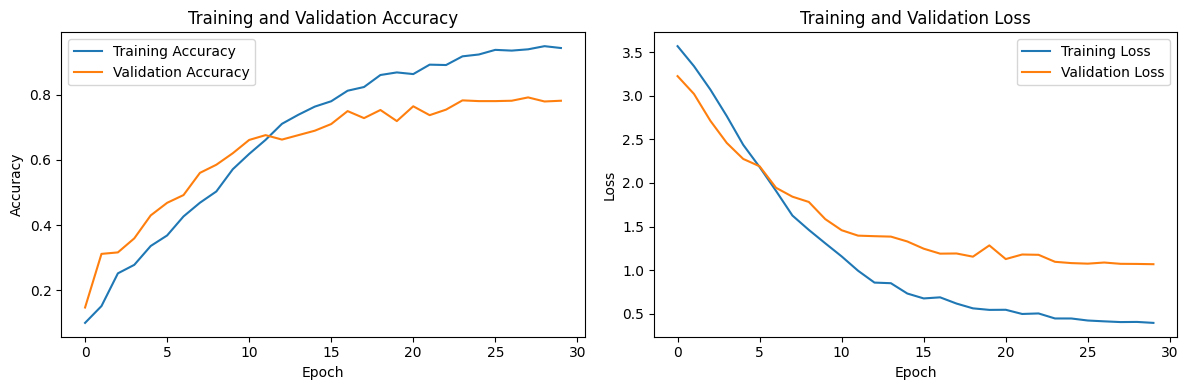

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
# 2. Courbes d'apprentissage (Accuracy et Loss)
plt.figure(figsize=(12, 4))
# Précision (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Perte (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
# Sauvegarde des courbes d'apprentissage
plt.savefig(save_dir / 'training_courbes_offer.png', dpi=300, bbox_inches='tight')
plt.show()

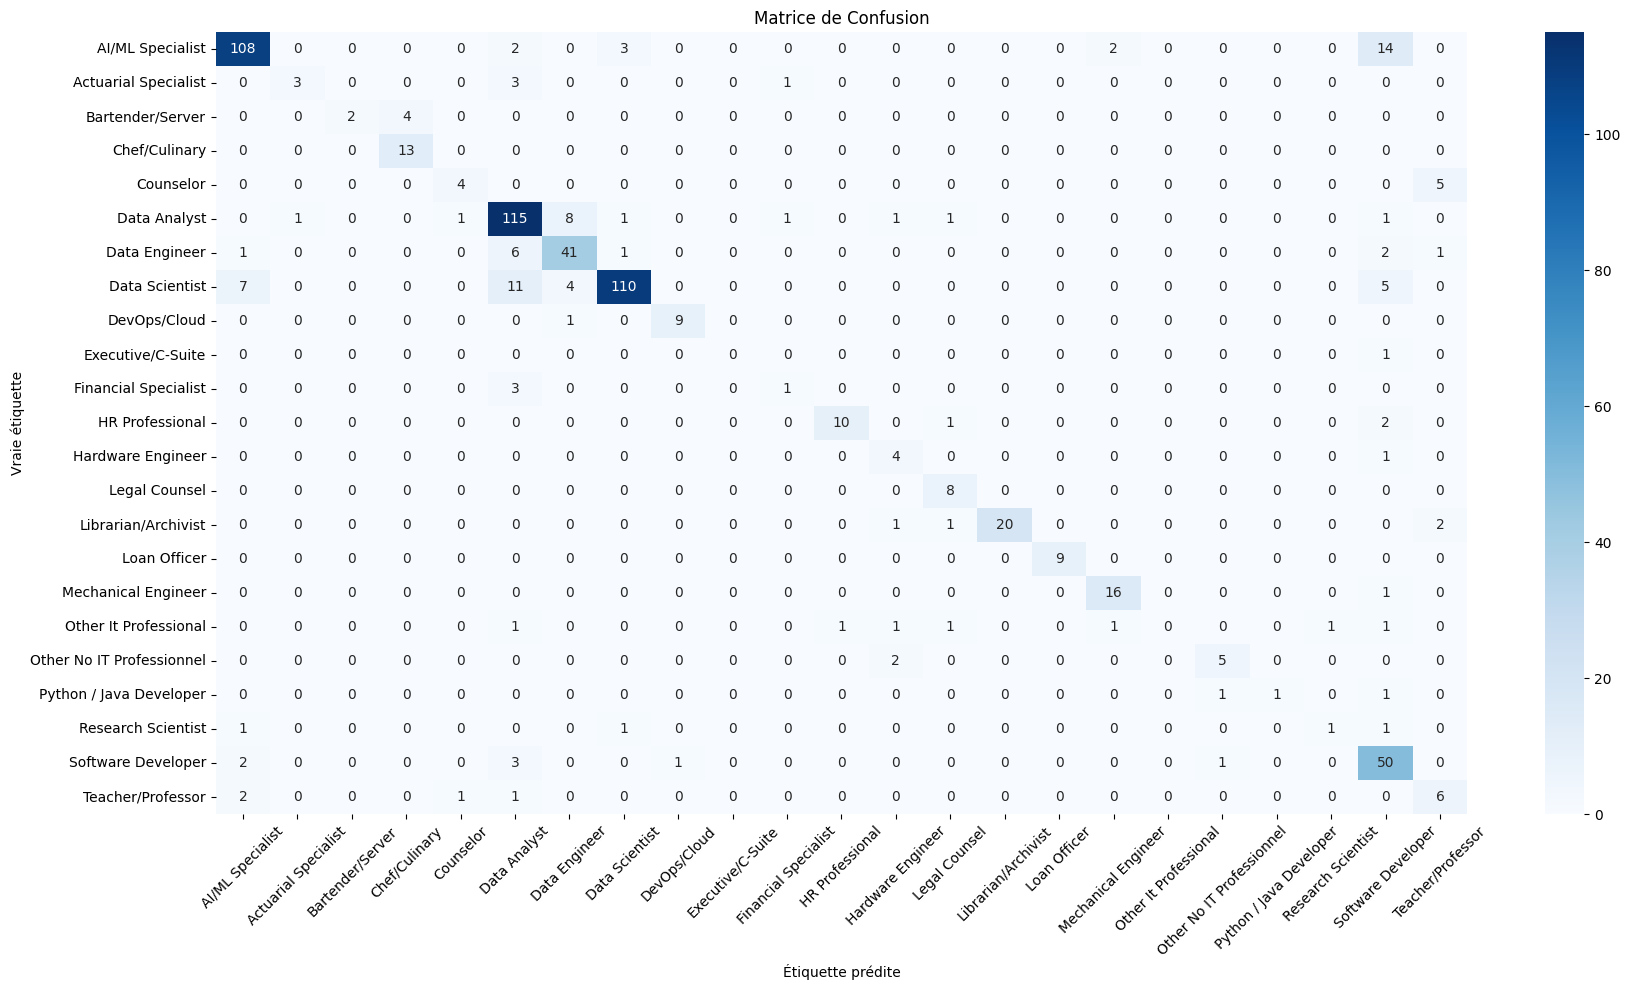

In [ ]:
plt.figure(figsize=(18, 10))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette')
plt.xlabel('Étiquette prédite')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(save_dir / 'confusion_matrix_seaborn_offer.png', dpi=300, bbox_inches='tight')
plt.show()